Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier

Step 2: Load Dataset

In [2]:
df = pd.read_csv("/content/creditcard.csv")
print(df.head())
print(df['Class'].value_counts())

     Time   Amount        V1        V2        V3        V4        V5  \
0  121958   134.17  1.749242  0.285690 -0.230932 -0.238271 -0.864070   
1  146867   458.82  0.794017 -1.066721  0.684843 -1.241042 -0.240662   
2  131932  1086.16  0.457537 -0.116630 -0.965233  1.458639 -1.216607   
3  103694   863.62 -1.193597 -0.723088 -0.611269 -0.181636  0.982033   
4  119879   666.30  0.935238 -0.401059 -1.167727  1.657142  1.717331   

         V6        V7        V8  ...       V20       V21       V22       V23  \
0 -0.592754 -0.284905 -0.142413  ... -0.496925  0.960871  0.474793 -0.931428   
1  1.369329 -0.567262 -0.708133  ... -1.246525  0.166603 -0.573194 -1.632434   
2 -0.079389  0.128481 -1.661279  ...  1.139845 -0.391956 -0.399728 -1.055647   
3  0.509139 -0.592644 -0.260669  ...  0.195042 -0.270249 -0.643047  1.517267   
4  0.501561  0.254206 -0.323815  ...  0.502350  1.377280  0.676223  0.331462   

        V24       V25       V26       V27       V28  Class  
0 -2.305303 -0.022552 -0.

Step 3: Check Class Imbalance

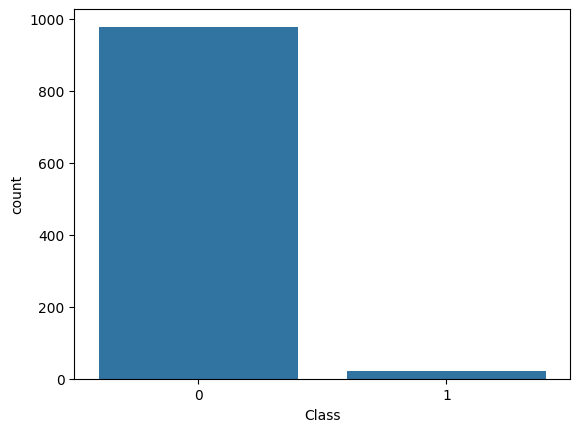

In [3]:
sns.countplot(x='Class', data=df)
plt.show()

🤖 3️⃣ Model 1 – Anomaly Detection (Isolation Forest)

In [4]:
X = df.drop('Class', axis=1)
y = df['Class']

iso_forest = IsolationForest(contamination=0.0017)
iso_forest.fit(X)

y_pred = iso_forest.predict(X)
y_pred = np.where(y_pred == -1, 1, 0)

In [5]:
print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred))

[[976   2]
 [ 22   0]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       978
           1       0.00      0.00      0.00        22

    accuracy                           0.98      1000
   macro avg       0.49      0.50      0.49      1000
weighted avg       0.96      0.98      0.97      1000



🚀 4️⃣ Model 2 – XGBoost (Supervised Model)

Split Data

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Scale Amount Column

In [7]:
scaler = StandardScaler()
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount'] = scaler.transform(X_test[['Amount']])

Train XGBoost

In [8]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight= len(y_train[y_train==0]) / len(y_train[y_train==1])
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Evaluate

In [9]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

[[195   1]
 [  4   0]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       196
           1       0.00      0.00      0.00         4

    accuracy                           0.97       200
   macro avg       0.49      0.50      0.49       200
weighted avg       0.96      0.97      0.97       200

ROC-AUC: 0.6237244897959183


In [14]:
import streamlit as st
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

def load_data():
    return pd.read_csv("/content/creditcard.csv")

def preprocess_data(df):
    X = df.drop('Class', axis=1)
    y = df['Class']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    scaler = StandardScaler()
    X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
    X_test['Amount'] = scaler.transform(X_test[['Amount']])
    return X_train, X_test, y_train, y_test

def train_xgboost(X_train, y_train):
    model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight= len(y_train[y_train==0]) / len(y_train[y_train==1])
    )
    model.fit(X_train, y_train)
    return model

st.title("💳 Credit Card Fraud Detection Dashboard")

df = load_data()

st.subheader("Dataset Overview")
st.write(df.head())

st.subheader("Fraud vs Normal Distribution")
st.bar_chart(df['Class'].value_counts())

if st.button("Train Model"):
    X_train, X_test, y_train, y_test = preprocess_data(df)
    model = train_xgboost(X_train, y_train)

    accuracy = model.score(X_test, y_test)

    st.success("Model Training Completed!")
    st.write("Model Accuracy:", accuracy)

    # Predict single sample
    sample = X_test.iloc[0:1]
    prediction = model.predict(sample)

    if prediction[0] == 1:
        st.error("⚠ Fraudulent Transaction Detected")
    else:
        st.success("✅ Normal Transaction")

2026-03-03 13:32:27.957 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 13:32:28.806 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-03 13:32:28.809 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 13:32:28.811 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 13:32:28.826 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 13:32:28.828 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 13:32:28.828 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-03 13:32:28.889 Thread 'MainThread': mi